In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("/content/clean_salary_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_sar
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413.0,411392.88
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764.0,352552.64
2,Frontend Developer,18,Phd,4,Media,Medium,Singapore,No,1,148123.0,556942.48
3,Business Analyst,19,Phd,13,Retail,Medium,Canada,Yes,0,189123.0,711102.48
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069.0,620659.44


In [4]:
df.tail()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_sar
249995,Software Engineer,17,Phd,2,Telecom,Enterprise,India,No,1,127791.0,480494.16
249996,Frontend Developer,20,Phd,7,Telecom,Startup,Remote,No,2,154593.0,581269.68
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988.0,285714.88
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467.0,340155.92
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084.0,500395.84


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 250000
Columns : 11


In [6]:
df.describe()

,experience_years,skills_count,certifications,salary,salary_sar
count,250000.000000,250000.000000,250000.000000,250000.000000,2.500000e+05
mean,10.005408,9.997812,2.491928,145718.080524,5.479000e+05
std,6.060602,5.479288,1.706475,37407.952729,1.406539e+05
min,0.000000,1.000000,0.000000,31867.000000,1.198199e+05
25%,5.000000,5.000000,1.000000,119358.000000,4.487861e+05
50%,10.000000,10.000000,2.000000,143453.000000,5.393833e+05
75%,15.000000,15.000000,4.000000,169492.000000,6.372899e+05
max,20.000000,19.000000,5.000000,333046.000000,1.252253e+06


In [7]:
df.describe(include="object")

,job_title,education_level,industry,company_size,location,remote_work
count,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21125,50352,25393,50254,25258,83621


In [8]:
missing = df.isnull().sum()

missing

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


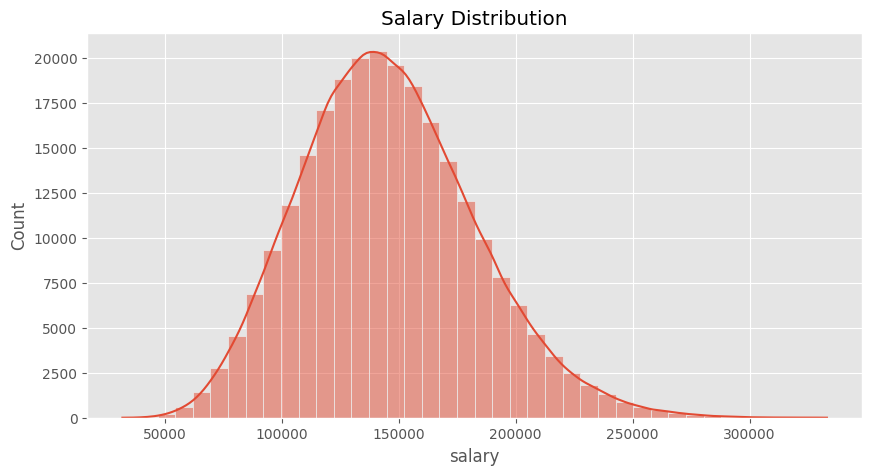

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df["salary"],bins=40,kde=True)

plt.title("Salary Distribution")
plt.show()

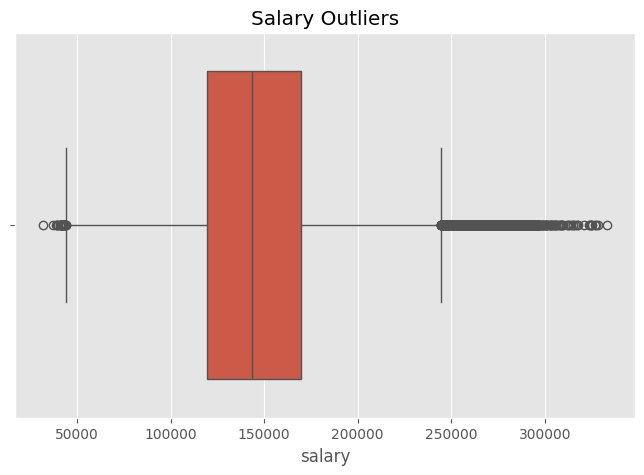

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["salary"])

plt.title("Salary Outliers")
plt.show()

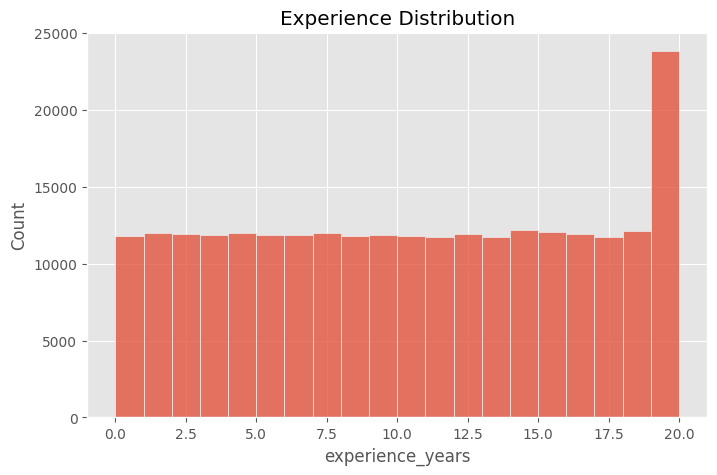

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["experience_years"],bins=20)

plt.title("Experience Distribution")

plt.show()

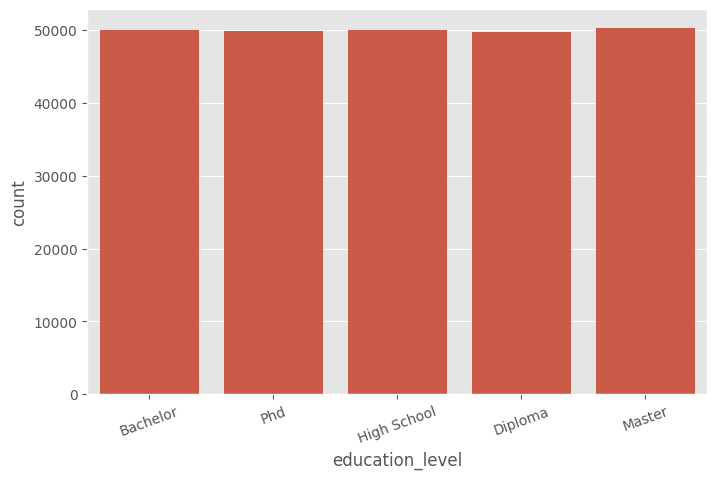

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="education_level")

plt.xticks(rotation=20)

plt.show()

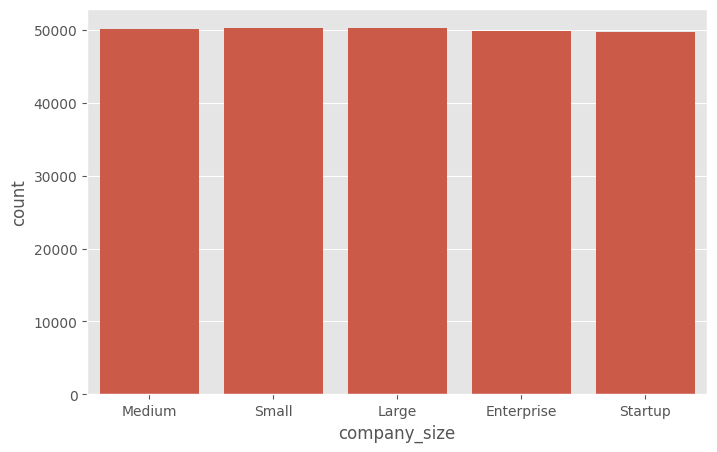

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="company_size")

plt.show()

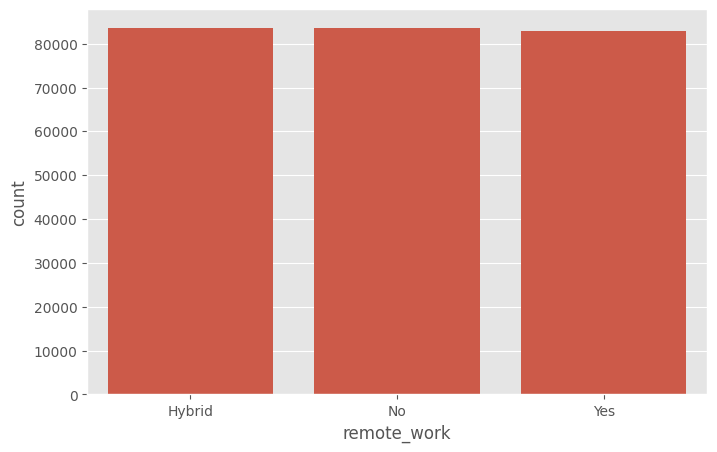

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="remote_work")

plt.show()

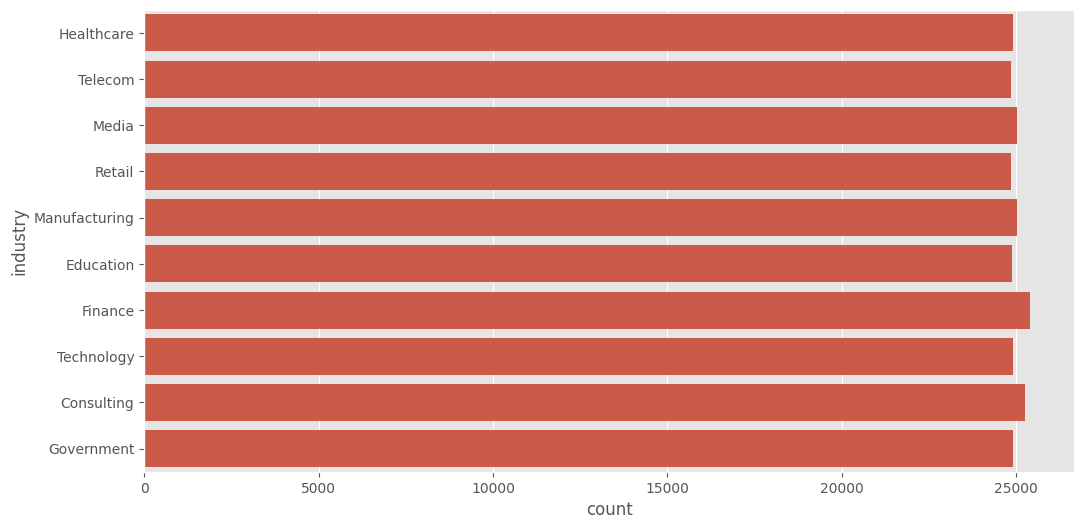

In [15]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,y="industry")

plt.show()

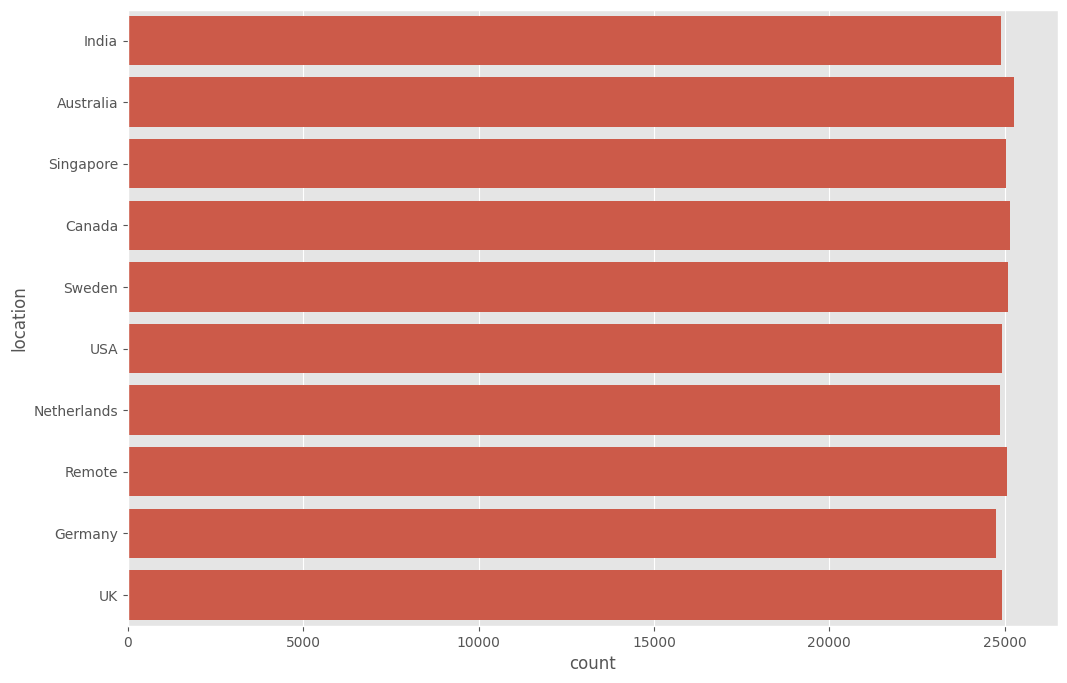

In [16]:
plt.figure(figsize=(12,8))

sns.countplot(data=df,y="location")

plt.show()

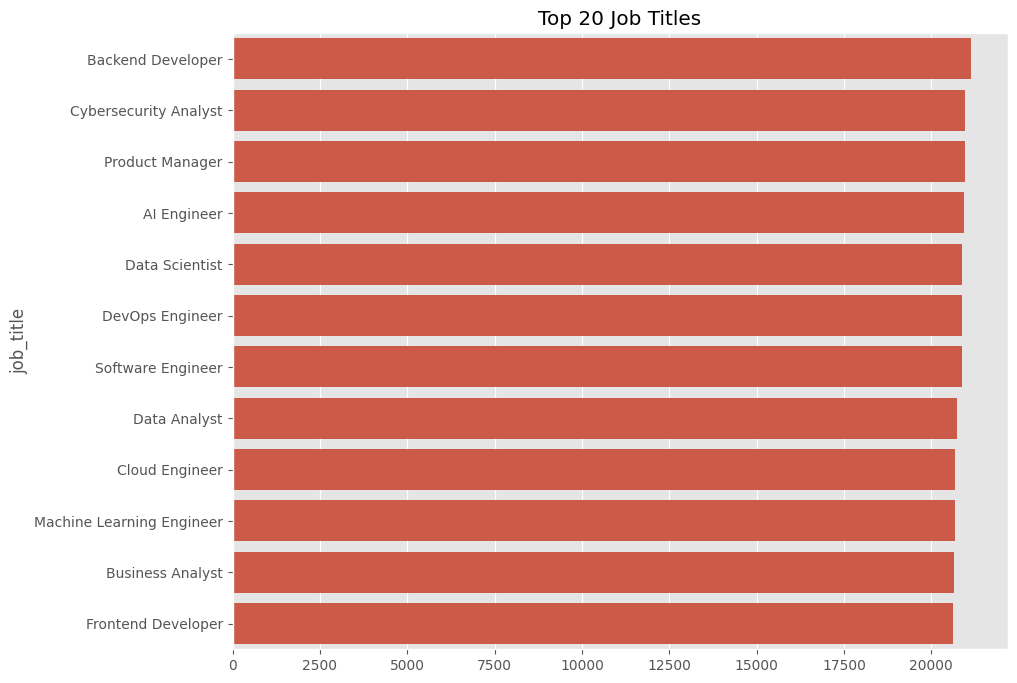

In [17]:
top_jobs = df["job_title"].value_counts().head(20)

plt.figure(figsize=(10,8))

sns.barplot(x=top_jobs.values,y=top_jobs.index)

plt.title("Top 20 Job Titles")

plt.show()

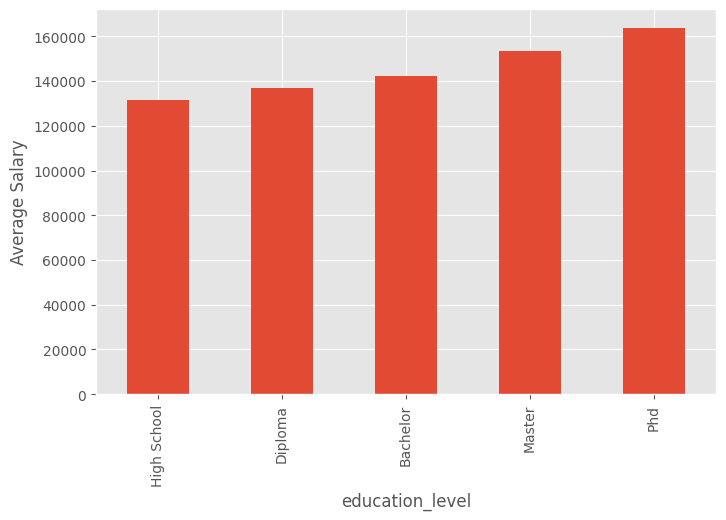

In [18]:
salary_edu = df.groupby("education_level")["salary"].mean().sort_values()

plt.figure(figsize=(8,5))

salary_edu.plot(kind="bar")

plt.ylabel("Average Salary")

plt.show()

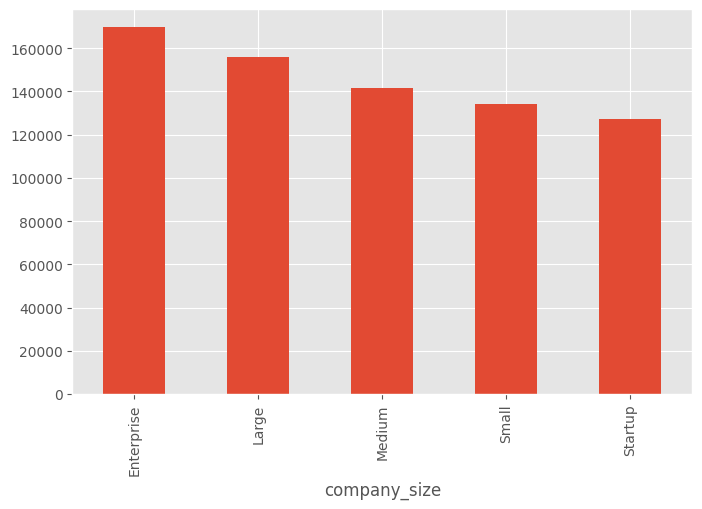

In [19]:
salary_company = df.groupby("company_size")["salary"].mean()

salary_company.plot(kind="bar",figsize=(8,5))

plt.show()

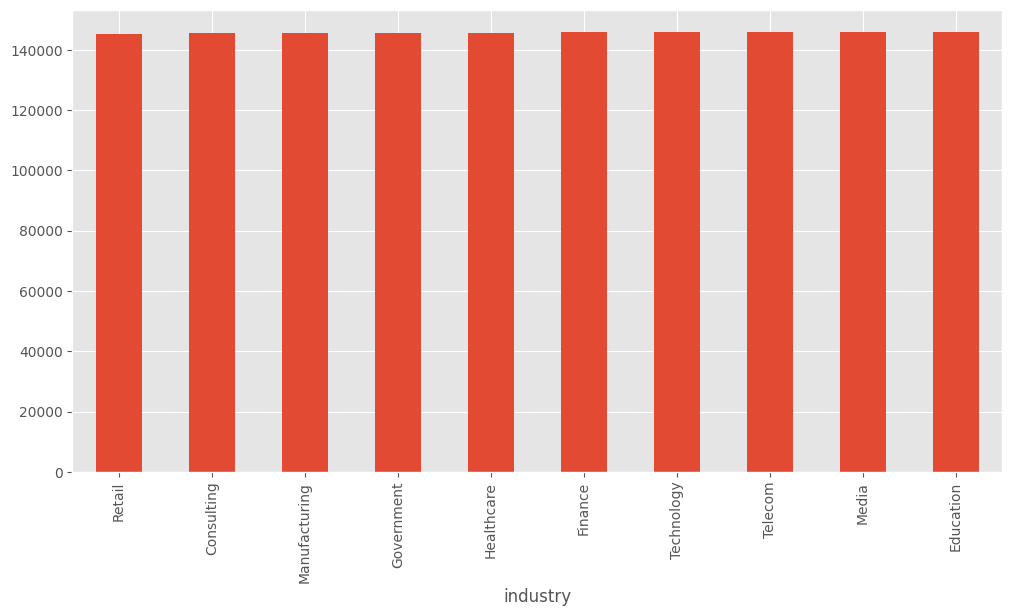

In [20]:
salary_industry = df.groupby("industry")["salary"].mean().sort_values()

plt.figure(figsize=(12,6))

salary_industry.plot(kind="bar")

plt.show()

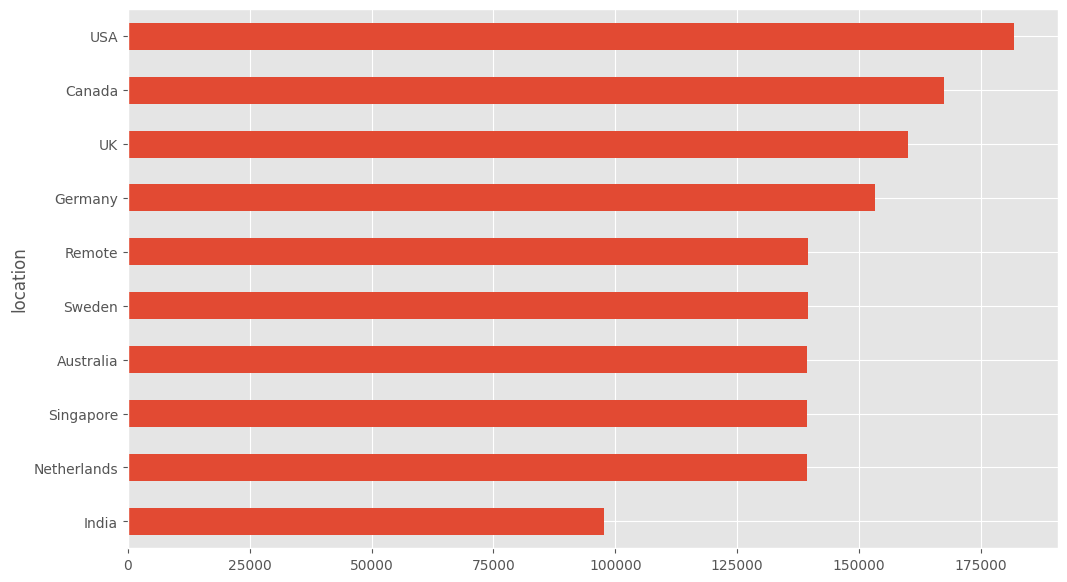

In [21]:
salary_location = df.groupby("location")["salary"].mean().sort_values()

plt.figure(figsize=(12,7))

salary_location.plot(kind="barh")

plt.show()

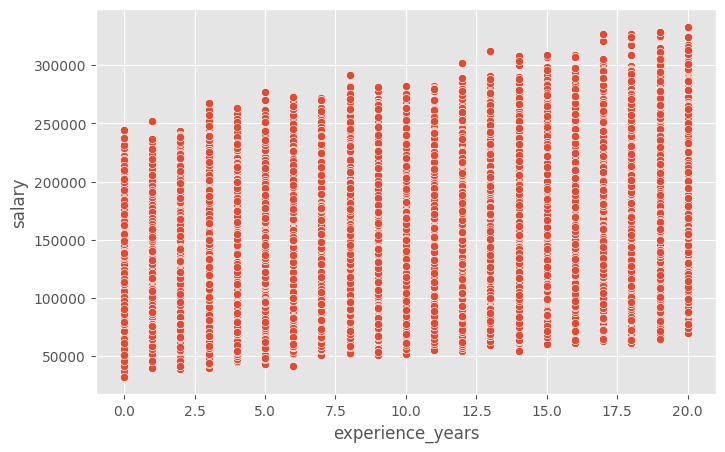

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="experience_years",
    y="salary"
)

plt.show()

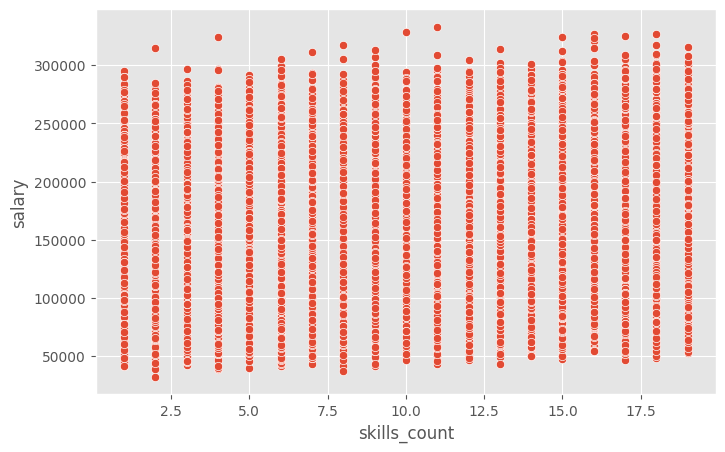

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="skills_count",
    y="salary"
)

plt.show()

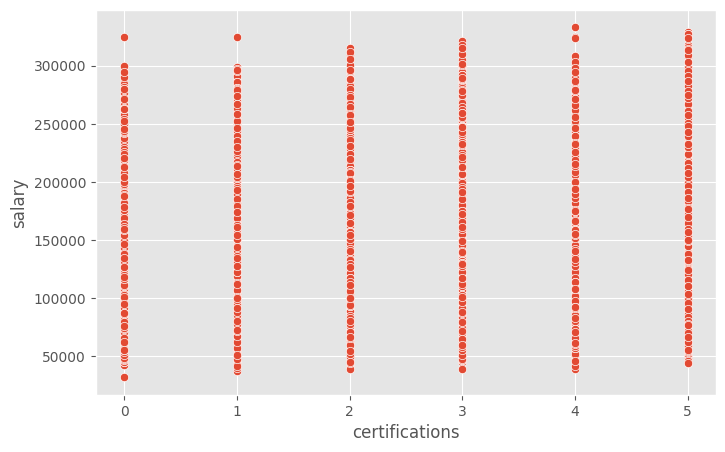

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="certifications",
    y="salary"
)

plt.show()

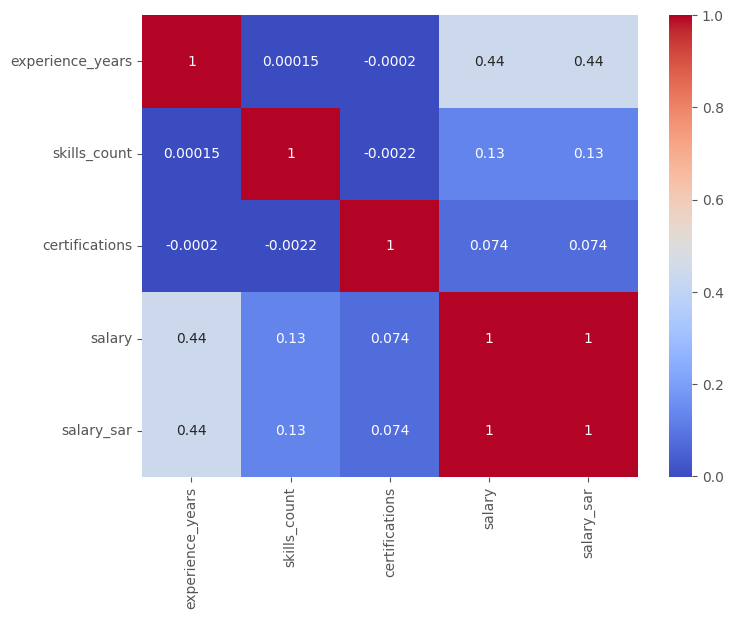

In [25]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

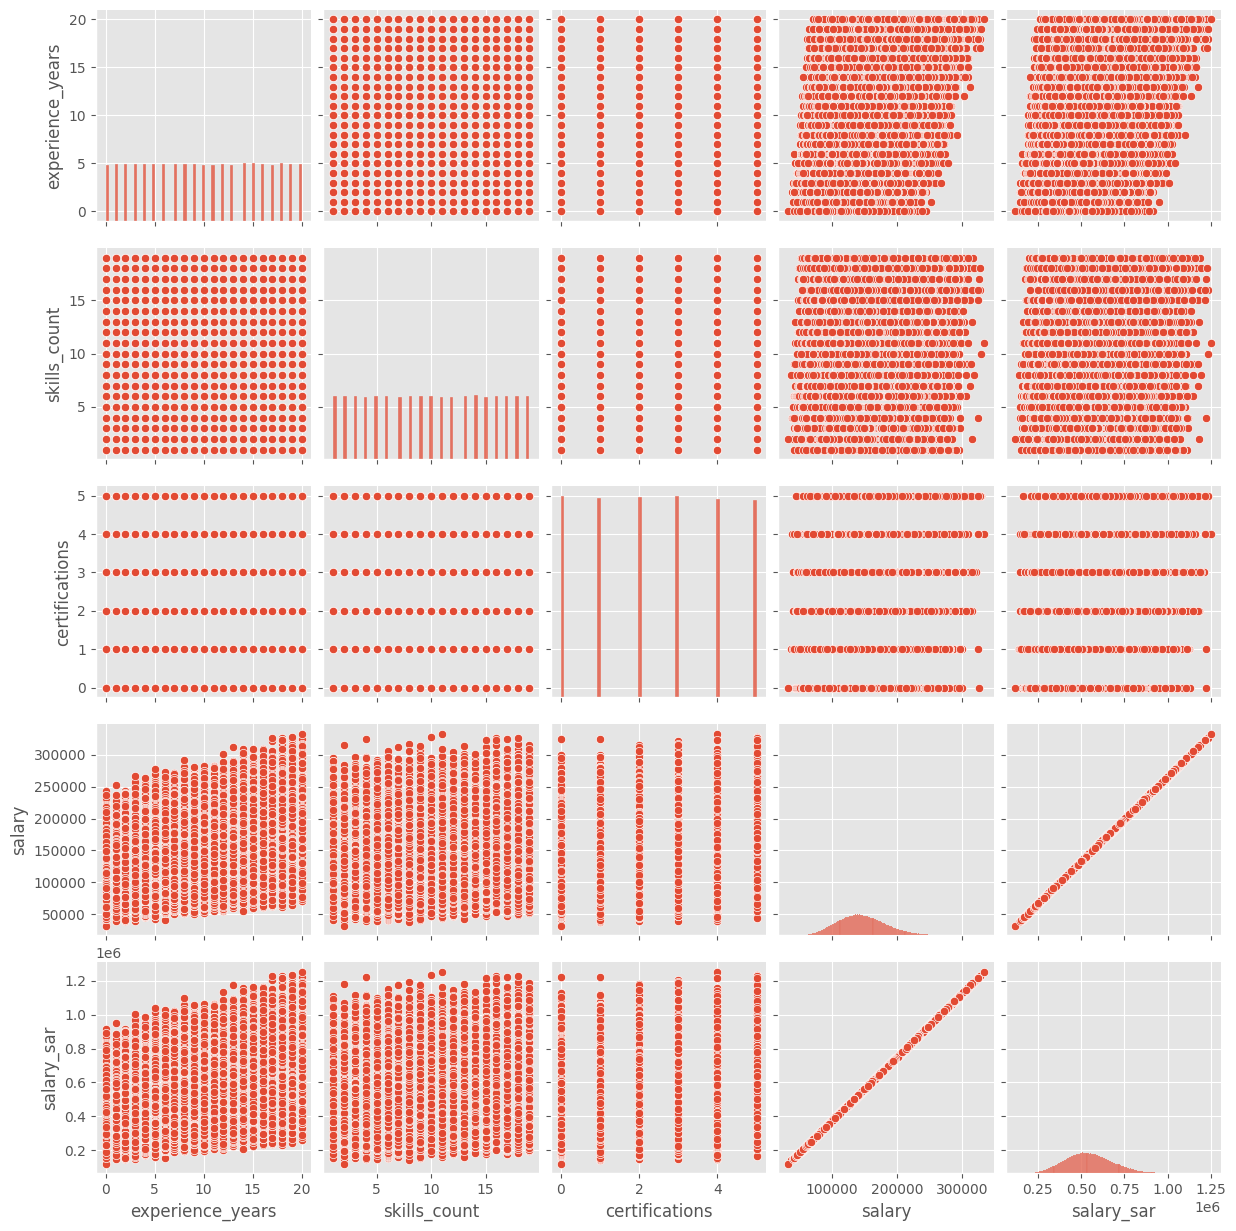

In [26]:
sns.pairplot(
    numeric
)

plt.show()

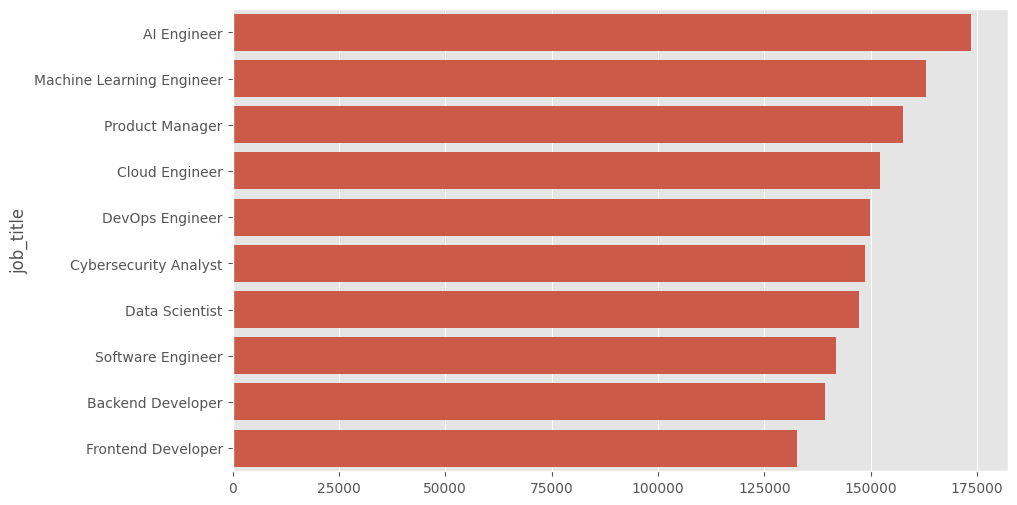

In [27]:
top_salary = df.groupby("job_title")["salary"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_salary.values,
    y=top_salary.index
)

plt.show()

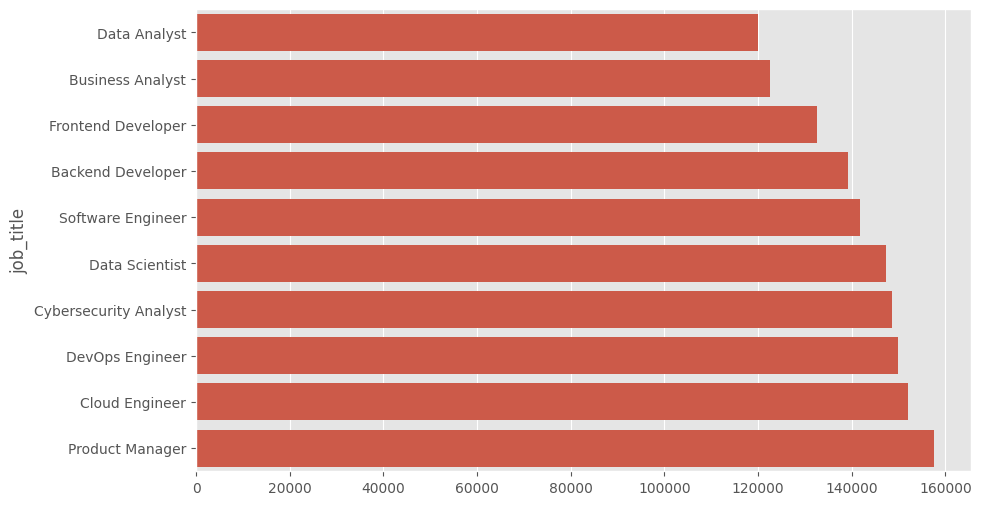

In [28]:
low_salary = df.groupby("job_title")["salary"].mean().sort_values().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=low_salary.values,
    y=low_salary.index
)

plt.show()

In [29]:
df.to_csv("/content/eda_salary_dataset.csv",index=False)

The dataset contains 250,000+ records.
There are 10 features.
No significant missing values.
The most frequent job title is ...
Salary generally increases with experience.
Certain industries have higher average salaries.
Larger companies tend to offer higher salaries.
Higher education and certifications are associated with increased salaries.
Remote work may show different salary patterns depending on role and location.